In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
import yfinance as yf

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, LSTM, GRU, Dense, Dropout, Input, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

warnings.simplefilter(action="ignore", category=FutureWarning)

In [3]:
import os
import random

def fijar_semillas(semilla=42):
    # 1. Fijar semilla de Python
    os.environ['PYTHONHASHSEED'] = str(semilla)
    random.seed(semilla)
    
    # 2. Fijar semilla de NumPy
    np.random.seed(semilla)
    
    # 3. Fijar semilla de TensorFlow/Keras
    tf.random.set_seed(semilla)
    
    print(f"[*] Semillas fijadas a {semilla} para asegurar reproducibilidad.")

# Llamar a la función antes de crear ningún modelo ni dividir datos
fijar_semillas(42)

[*] Semillas fijadas a 42 para asegurar reproducibilidad.


In [24]:
# =====================================================================
# 1. DESCARGA Y PREPARACIÓN DE DATOS 
# =====================================================================
print("Descargando datos de Yahoo Finance...")
start_date = '1960-01-01'
tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 
                   'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 
                   'MSI', 'PG', 'XOM']

datos_yahoo = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=False)
precios_close = datos_yahoo['Close'].dropna(axis=1)

# Cálculo de retornos logarítmicos
returns = np.log(precios_close).diff().dropna()
print(f"Forma de los datos de retornos: {returns.shape}")

# Función del profesor para crear ventanas
def create_time_series_data(data, input_window_size, output_window_size):
    X, y = [], []
    data_array = data.values if isinstance(data, pd.DataFrame) else data
    num_features = data_array.shape[1] 

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)
        
        if output_window_size > 0:
            output_sequence = data_array[i + input_window_size : i + input_window_size + output_window_size]
            average_output = np.mean(output_sequence, axis=0) 
            y.append(average_output)
        else:
            y.append(data_array[i + input_window_size - 1])
            
    return np.array(X), np.array(y)

Descargando datos de Yahoo Finance...


c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:144: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:144: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a f

Forma de los datos de retornos: (16199, 23)


In [27]:
# Crear carpeta para guardar gráficas si no existe
os.makedirs('graficas_convergencia_regresion_lineal', exist_ok=True)

# Crear carpeta para gráficas
os.makedirs('graficas_convergencia_cnn_tbm', exist_ok=True)

In [28]:
# =====================================================================
# 1. DESCARGA Y PREPARACIÓN DE DATOS: PORTFOLIO DOLLAR BARS
# =====================================================================

# precios_close = datos_yahoo['Close'].dropna(axis=1) esta en la anterior celda
volumenes = datos_yahoo['Volume'].dropna(axis=1)

print(f"Datos cronológicos originales (Time Bars): {precios_close.shape}")

# ---------------------------------------------------------------------
# A) Cálculo del Dollar Volume del Portfolio
# ---------------------------------------------------------------------
# Multiplicamos precio por volumen para cada activo (Dólares negociados por empresa y día)
dollar_volume_individual = precios_close * volumenes

# Sumamos horizontalmente para obtener los Dólares negociados por TODAS las 23 empresas ese día
portfolio_dollar_volume = dollar_volume_individual.sum(axis=1)


# ---------------------------------------------------------------------
# B) Función de Muestreo de Dollar Bars
# ---------------------------------------------------------------------
def sample_portfolio_dollar_bars(df_precios, serie_dollar_vol, threshold):
    """
    Recorre la serie cronológica acumulando dólares negociados.
    Cuando el acumulado supera el 'threshold' (umbral), guarda la fecha,
    cierra la barra y resetea el contador.
    """
    fechas_barras = []
    vol_acumulado = 0.0
    
    # Extraemos fechas y volúmenes para iterar rápidamente
    fechas = serie_dollar_vol.index
    volumenes_diarios = serie_dollar_vol.values
    
    for fecha, vol in zip(fechas, volumenes_diarios):
        # Ignoramos NaNs que puedan surgir en datos muy antiguos
        if np.isnan(vol):
            continue
            
        vol_acumulado += vol
        
        # ¿Hemos superado la "Triple Barrera" de volumen de dinero?
        if vol_acumulado >= threshold:
            fechas_barras.append(fecha)
            vol_acumulado = 0.0  # Reset de la barra
            
    # Filtramos la matriz original de 23 activos usando solo las fechas donde se cerró una barra
    return df_precios.loc[fechas_barras]

# ---------------------------------------------------------------------
# C) Generación de la nueva matriz indexada por Información
# ---------------------------------------------------------------------
# Definir el umbral (Threshold). 
# Prado recomienda usar una fracción del volumen total, o un múltiplo de la media diaria.
# Por ejemplo: queremos que cada barra contenga la cantidad de dólares que, EN MEDIA, se negocian en 5 días.
umbral_dolares = portfolio_dollar_volume.mean() * 5 

precios_dollar_bars = sample_portfolio_dollar_bars(precios_close, portfolio_dollar_volume, umbral_dolares)

print(f"Nueva matriz tras compresión (Portfolio Dollar Bars): {precios_dollar_bars.shape}")

# (NOTA: Aún no calculamos retornos. Dejaremos precios_dollar_bars intacto para aplicarle FracDiff después)


# =====================================================================
# 2. TRANSFORMACIÓN LÓPEZ DE PRADO: DIFERENCIACIÓN FRACCIONARIA (FFD)
# =====================================================================

def obtener_pesos_fracdiff(d, umbral=1e-4):
    """
    Calcula los pesos para la diferenciación fraccionaria.
    Los pesos disminuyen iterativamente. Se cortan cuando el valor
    absoluto del peso es menor que el 'umbral' (threshold).
    """
    w = [1.]
    k = 1
    while True:
        # Fórmula matemática recursiva de López de Prado para los pesos
        w_k = -w[-1] / k * (d - k + 1)
        if abs(w_k) < umbral:
            break
        w.append(w_k)
        k += 1
    
    # Invertimos los pesos para aplicarlos cronológicamente (el más reciente tiene peso 1)
    return np.array(w[::-1])

def aplicar_fracdiff_ffd(df_precios, d, umbral=1e-4):
    """
    Aplica FracDiff a un DataFrame entero usando una ventana fija (FFD).
    Esto evita la pérdida excesiva de datos al inicio de la serie.
    """
    print(f"Calculando Diferenciación Fraccionaria con d={d}...")
    
    # 1. Obtener los pesos matemáticos
    w = obtener_pesos_fracdiff(d, umbral)
    ventana = len(w)
    print(f"Tamaño de la ventana de memoria (días/barras retenidas): {ventana}")
    
    # Transformamos el DF a logaritmos para estabilizar la varianza antes de diferenciar
    df_log = np.log(df_precios)
    
    # 2. Crear un DataFrame vacío para los resultados
    df_diff = pd.DataFrame(index=df_log.index, columns=df_log.columns)
    
    # 3. Aplicar el producto punto (dot product) deslizando la ventana
    # Multiplicamos el vector de pesos (1D) por la matriz de precios de la ventana (2D)
    for i in range(ventana - 1, len(df_log)):
        # Tomamos el bloque temporal exacto de tamaño 'ventana' hasta el día 'i'
        corte = df_log.iloc[i - ventana + 1 : i + 1]
        
        # np.dot suma el peso histórico * precio histórico para los 23 activos a la vez
        df_diff.iloc[i] = np.dot(w, corte.values)
        
    # Eliminamos las primeras filas que no tenían historia suficiente para llenar la ventana
    return df_diff.dropna().astype(float)


# ---------------------------------------------------------------------
# EJECUCIÓN DEL ALGORITMO FRACDIFF
# ---------------------------------------------------------------------
# El parámetro 'd' (grado de diferenciación). 
# En el SP500, un valor entre 0.4 y 0.5 suele ser el punto dulce donde
# la serie se vuelve estacionaria (ADF test < 0.05) pero retiene >70% de memoria.
grado_d = 0.45 

# Reemplazamos tu antiguo: returns = np.log(precios_close).diff().dropna()
# Por la nueva matriz con memoria:
fracdiff_features = aplicar_fracdiff_ffd(precios_dollar_bars, d=grado_d)

print(f"Forma de los datos FracDiff finales: {fracdiff_features.shape}")


from tensorflow.keras.utils import to_categorical

# =====================================================================
# 3. TRIPLE BARRIER METHOD Y ARQUITECTURA CNN
# =====================================================================

def create_triple_barrier_data(data_features, data_prices, input_window_size, output_window_size, pt_limit, sl_limit):
    """
    Genera etiquetas de clasificación usando el Método de la Triple Barrera.
    """
    X, y = [], []
    
    features_array = data_features.values if isinstance(data_features, pd.DataFrame) else data_features
    precios_array = data_prices.mean(axis=1).values if isinstance(data_prices, pd.DataFrame) else data_prices

    for i in range(len(features_array) - input_window_size - output_window_size + 1):
        # 1. Ventana de Entrada (Input Features: FracDiff)
        input_sequence = features_array[i : i + input_window_size]
        X.append(input_sequence)
        
        # 2. Trayectoria Futura (Output: Precios reales para la barrera)
        p0 = precios_array[i + input_window_size - 1]
        future_prices = precios_array[i + input_window_size : i + input_window_size + output_window_size]
        
        path_returns = (future_prices / p0) - 1
        
        # 3. Lógica de la Triple Barrera
        etiqueta = 1  # Por defecto, Clase 1 (Plano)
        
        for r in path_returns:
            if r >= pt_limit:
                etiqueta = 2  # Clase 2 (Sube)
                break
            elif r <= -sl_limit:
                etiqueta = 0  # Clase 0 (Baja)
                break
                
        y.append(etiqueta)

    X = np.array(X)
    y = to_categorical(y, num_classes=3)
    
    return X, y

Datos cronológicos originales (Time Bars): (16200, 23)
Nueva matriz tras compresión (Portfolio Dollar Bars): (2506, 23)
Calculando Diferenciación Fraccionaria con d=0.45...
Tamaño de la ventana de memoria (días/barras retenidas): 238
Forma de los datos FracDiff finales: (2269, 23)


In [29]:
def construir_campeon_regresion(input_shape=(90, 23)):
    modelo = Sequential()
    modelo.add(Input(shape=input_shape))
    
    # 1. Extracción de patrones sutiles
    modelo.add(Conv1D(filters=8, kernel_size=3, padding='same', activation='relu'))
    
    # 2. Memoria temporal ultra-restringida
    modelo.add(LSTM(8, return_sequences=False))
    
    # 3. Freno de mano masivo (Dropout 50%)
    modelo.add(Dropout(0.5))
    
    # 4. Salida: 23 valores continuos (Regresión)
    modelo.add(Dense(23, activation='linear')) 
    
    modelo.compile(optimizer=Adam(learning_rate=0.0001), loss='mae')
    return modelo


In [30]:
def construir_campeon_prado(input_shape=(90, 23)):
    modelo = Sequential()
    modelo.add(Input(shape=input_shape))
    
    # 1. Extracción de patrones masiva (Double Conv)
    modelo.add(Conv1D(filters=256, kernel_size=3, padding='same', activation='relu'))
    modelo.add(Conv1D(filters=256, kernel_size=3, padding='same', activation='relu'))
    
    # Promediado Global (Alternativa a Flatten recomendada cuando flatten=False)
    modelo.add(GlobalAveragePooling1D())
    
    # 2. Regularización
    modelo.add(Dropout(0.2))
    
    # 3. Salida: 3 Probabilidades de la Triple Barrera (Clasificación)
    modelo.add(Dense(3, activation='softmax'))
    
    modelo.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return modelo


Preparando tuberías de datos...

Entrenando Campeón 1: Regresión Clásica...
Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 9/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 10/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 11/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step

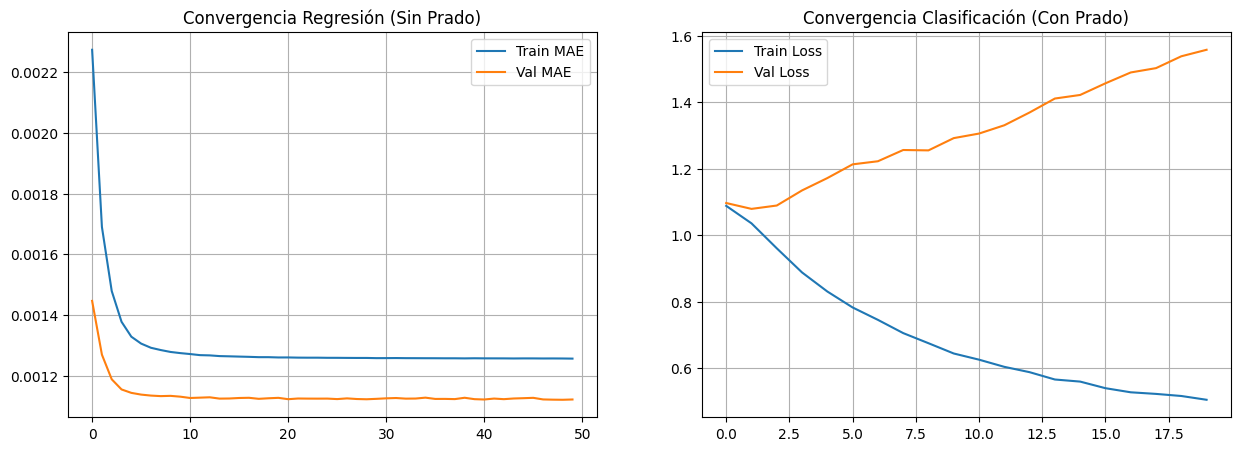

In [39]:
# =====================================================================
# 1. PREPARACIÓN DE DATOS Y SPLIT CRONOLÓGICO (70% - 20% - 10%)
# =====================================================================
print("Preparando tuberías de datos...")

IN_W = 90
OUT_W = 90

# --- TUBERÍA A: REGRESIÓN (SIN PRADO) ---
X_reg, y_reg = create_time_series_data(returns, IN_W, OUT_W)

split_1_reg = int(len(X_reg) * 0.70)
split_2_reg = int(len(X_reg) * 0.90)

X_train_reg, y_train_reg = X_reg[:split_1_reg], y_reg[:split_1_reg]
X_val_reg, y_val_reg = X_reg[split_1_reg:split_2_reg], y_reg[split_1_reg:split_2_reg]
X_test_reg, y_test_reg = X_reg[split_2_reg:], y_reg[split_2_reg:]

# --- TUBERÍA B: CLASIFICACIÓN (CON PRADO) ---
pt_dinamico = 0.01 + (0.001 * OUT_W)
sl_dinamico = 0.01 + (0.001 * OUT_W)

X_pra, y_pra = create_triple_barrier_data(
    fracdiff_features, precios_dollar_bars, IN_W, OUT_W, 
    pt_limit=pt_dinamico, sl_limit=sl_dinamico
)

split_1_pra = int(len(X_pra) * 0.70)
split_2_pra = int(len(X_pra) * 0.90)

X_train_pra, y_train_pra = X_pra[:split_1_pra], y_pra[:split_1_pra]
X_val_pra, y_val_pra = X_pra[split_1_pra:split_2_pra], y_pra[split_1_pra:split_2_pra]
X_test_pra, y_test_pra = X_pra[split_2_pra:], y_pra[split_2_pra:]

# Calculamos los pesos de clase para Prado para evitar desbalanceo
from sklearn.utils.class_weight import compute_class_weight
y_train_enteros = np.argmax(y_train_pra, axis=1)
clases_unicas = np.unique(y_train_enteros)
pesos = compute_class_weight(class_weight='balanced', classes=clases_unicas, y=y_train_enteros)
pesos_prado = dict(zip(clases_unicas, pesos))

# =====================================================================
# 2. CONSTRUCCIÓN Y ENTRENAMIENTO DE LOS CAMPEONES
# =====================================================================
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# --- CAMPEÓN 1: REGRESIÓN (CNN + LSTM) ---
print("\nEntrenando Campeón 1: Regresión Clásica...")
modelo_regresion = construir_campeon_regresion()

historial_reg = modelo_regresion.fit(
    X_train_reg, y_train_reg, validation_data=(X_val_reg, y_val_reg),
    epochs=50, batch_size=64, callbacks=[early_stop], verbose=1
)

# --- CAMPEÓN 2: LÓPEZ DE PRADO (CNN Double Conv) ---
print("\nEntrenando Campeón 2: López de Prado (Triple Barrera)...")
modelo_prado = modelo_prado = Sequential([
    Input(shape=(IN_W, 23)),
    Conv1D(filters=256, kernel_size=3, padding='same', activation='relu'),
    Conv1D(filters=256, kernel_size=3, padding='same', activation='relu'),
    GlobalAveragePooling1D(), # Sustituye al Flatten como indicaba tu configuración
    Dropout(0.2),
    Dense(3, activation='softmax')
])
modelo_prado.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

historial_pra = modelo_prado.fit(
    X_train_pra, y_train_pra, validation_data=(X_val_pra, y_val_pra),
    epochs=50, batch_size=64, class_weight=pesos_prado, callbacks=[early_stop], verbose=1
)

# =====================================================================
# 3. GRÁFICAS DE CONVERGENCIA
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica Regresión (MAE)
axes[0].plot(historial_reg.history['loss'], label='Train MAE')
axes[0].plot(historial_reg.history['val_loss'], label='Val MAE')
axes[0].set_title('Convergencia Regresión (Sin Prado)')
axes[0].legend()
axes[0].grid(True)

# Gráfica Prado (Loss)
axes[1].plot(historial_pra.history['loss'], label='Train Loss')
axes[1].plot(historial_pra.history['val_loss'], label='Val Loss')
axes[1].set_title('Convergencia Clasificación (Con Prado)')
axes[1].legend()
axes[1].grid(True)

plt.savefig('convergencia_final_campeones.png')
plt.show()


In [40]:
# =====================================================================
# CELDA: BACKTESTING IA CLÁSICA (REGRESIÓN)
# =====================================================================
print("Calculando Backtesting para Regresión...")

capital_inicial = 10000
cap_bh_reg = [capital_inicial]
cap_reg = [capital_inicial]

# Predicciones
predicciones_reg = modelo_regresion.predict(X_test_reg, verbose=0)
# Retorno real (promedio de los 23 activos en cada paso de tiempo)
retornos_reales_reg = np.mean(y_test_reg, axis=1)

for i in range(len(predicciones_reg)):
    retorno_hoy = retornos_reales_reg[i]
    
    # Benchmark
    cap_bh_reg.append(cap_bh_reg[-1] * (1 + retorno_hoy))
    
    # Estrategia: Invertir si la media predicha es positiva
    esperado = np.mean(predicciones_reg[i])
    if esperado > 0:
        cap_reg.append(cap_reg[-1] * (1 + retorno_hoy))
    else:
        cap_reg.append(cap_reg[-1]) # Efectivo

print(f"✅ Backtesting Regresión completado. Pasos: {len(predicciones_reg)}")

Calculando Backtesting para Regresión...
✅ Backtesting Regresión completado. Pasos: 1602


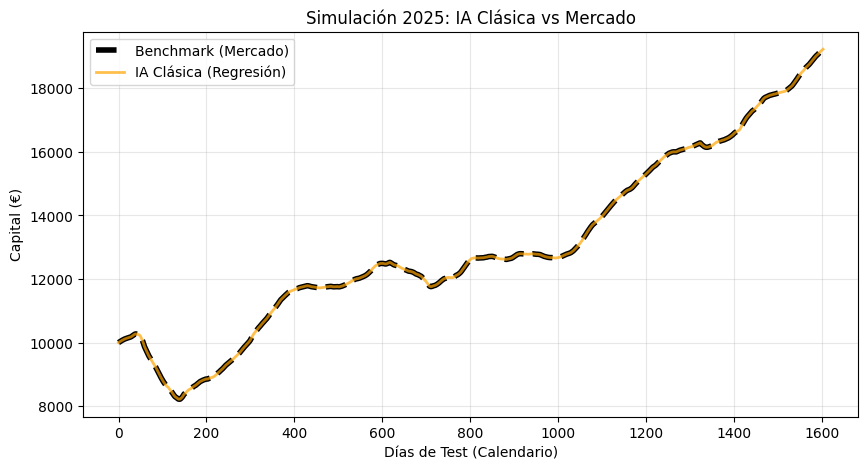

Resultado Final Benchmark: 19227.45 € (92.27%)
Resultado Final Regresión: 19227.45 € (92.27%)


In [41]:
# =====================================================================
# CELDA: GRÁFICA IA CLÁSICA
# =====================================================================
plt.figure(figsize=(10, 5))
# Hacemos el Benchmark más grueso (linewidth=4)
plt.plot(cap_bh_reg, label='Benchmark (Mercado)', color='black', linestyle='--', linewidth=4)

# Hacemos la IA un poco más fina y transparente (alpha=0.7)
plt.plot(cap_reg, label='IA Clásica (Regresión)', color='orange', linewidth=2, alpha=0.7)
plt.title('Simulación 2025: IA Clásica vs Mercado')
plt.xlabel('Días de Test (Calendario)')
plt.ylabel('Capital (€)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo del porcentaje de ganancia/pérdida
rentabilidad_reg = ((cap_reg[-1] - capital_inicial) / capital_inicial) * 100
rentabilidad_bh_reg = ((cap_bh_reg[-1] - capital_inicial) / capital_inicial) * 100

print(f"Resultado Final Benchmark: {cap_bh_reg[-1]:.2f} € ({rentabilidad_bh_reg:.2f}%)")
print(f"Resultado Final Regresión: {cap_reg[-1]:.2f} € ({rentabilidad_reg:.2f}%)")

In [42]:
# =====================================================================
# CELDA: BACKTESTING LÓPEZ DE PRADO (CLASIFICACIÓN)
# =====================================================================
print("Calculando Backtesting para López de Prado...")

cap_bh_pra = [capital_inicial]
cap_pra = [capital_inicial]

# Predicciones
predicciones_pra = modelo_prado.predict(X_test_pra, verbose=0)

# IMPORTANTE: Aquí usamos los retornos que corresponden a las Dollar Bars de Test
# Si no tienes 'y_test_pra_retornos', calculamos el retorno del portfolio en esas barras
retornos_reales_pra = np.mean(y_test_reg[:len(predicciones_pra)], axis=1) 

for i in range(len(predicciones_pra)):
    retorno_hoy = retornos_reales_pra[i]
    
    # Benchmark
    cap_bh_pra.append(cap_bh_pra[-1] * (1 + retorno_hoy))
    
    # Estrategia: Invertir si la clase es 2 (Sube)
    clase = np.argmax(predicciones_pra[i])
    if clase == 2:
        cap_pra.append(cap_pra[-1] * (1 + retorno_hoy))
    else:
        cap_pra.append(cap_pra[-1]) # Efectivo

print(f"✅ Backtesting Prado completado. Pasos (Dollar Bars): {len(predicciones_pra)}")

Calculando Backtesting para López de Prado...
✅ Backtesting Prado completado. Pasos (Dollar Bars): 209


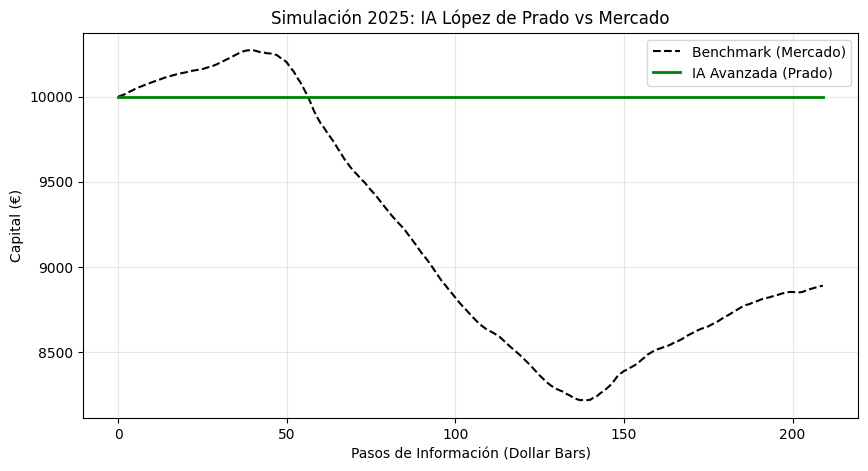

Resultado Final Benchmark: 8891.38 € (-11.09%)
Resultado Final Prado:     10000.00 € (0.00%)


In [43]:
# =====================================================================
# CELDA: GRÁFICA LÓPEZ DE PRADO
# =====================================================================
plt.figure(figsize=(10, 5))
plt.plot(cap_bh_pra, label='Benchmark (Mercado)', color='black', linestyle='--')
plt.plot(cap_pra, label='IA Avanzada (Prado)', color='green', linewidth=2)
plt.title('Simulación 2025: IA López de Prado vs Mercado')
plt.xlabel('Pasos de Información (Dollar Bars)')
plt.ylabel('Capital (€)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo del porcentaje de ganancia/pérdida
rentabilidad_pra = ((cap_pra[-1] - capital_inicial) / capital_inicial) * 100
rentabilidad_bh_pra = ((cap_bh_pra[-1] - capital_inicial) / capital_inicial) * 100

print(f"Resultado Final Benchmark: {cap_bh_pra[-1]:.2f} € ({rentabilidad_bh_pra:.2f}%)")
print(f"Resultado Final Prado:     {cap_pra[-1]:.2f} € ({rentabilidad_pra:.2f}%)")